<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/mariano/mariano_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Parte 2: Análisis exploratorio y curación de datos

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*

**Objetivo**: responder al menos tres de las preguntas planteadas por el grupo en el trabajo práctico 1.

Se espera un manejo más avanzado del set de datos, en donde el grupo de trabajo relacione las distintas columnas del dataset (variables) para responder preguntas con una complejidad mayor que la de realizar una mera descripción.

Cada respuesta a cada pregunta debe contener los siguientes apartados para considerarse completa:

1. **Planteo de la pregunta.** Se deben incluir las implicancias o las consecuencias de poder responderla. Por ejemplo, si la pregunta es ¿cuándo presentan mayor cantidad de huevos las hembras de cada una de las especies? Tiene implicancia directa en el manejo pesquero de la especie. Explicitar.

2. **Desarrollo del paso a paso que se hizo para responder a la pregunta.** Por ejemplo, ¿cómo se consideraron los datos faltantes? ¿qué individuos se consideraron y cuáles no?

3. Al menos **un gráfico por pregunta respondida**, así como su interpretación.

In [109]:
# Librerias utilizadas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import re

sns.set_context('talk')
pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 400

In [110]:
# Importo dataset original
url_original_data = "https://raw.github.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv"
data_original = pd.read_csv(url_original_data, sep=';', engine='python', encoding='latin1')

In [111]:
# Cargo el CSV local guardado en Drive con datos jul97
url_jul97 = 'https://raw.github.com/Mariano-ds/centollas2026/main/datos/jul97.csv'
data_jul97 = pd.read_csv(url_jul97, sep=';', engine='python', encoding='utf-8-sig')

In [112]:
# Estandarizacion previa - nombres de columnas
data_original.columns = data_original.columns.str.strip().str.lower()
data_jul97.columns = data_jul97.columns.str.strip().str.lower()

# Concatenar los DataFrames
# axis=0 une por filas alineando automáticamente por nombre de columna
# ignore_index=True reindexa las filas de 0 a N para evitar índices repetidos
df_full = pd.concat([data_original, data_jul97], axis=0, ignore_index=True)

# Confirmación de la estructura unificada
print(f"Filas totales: {df_full.shape[0]} | Columnas totales: {df_full.shape[1]}")
df_raw = df_full.copy()
df_raw.head(2)

Filas totales: 13114 | Columnas totales: 20


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,unnamed: 18,unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


### Informacion acerca de las variables

Datos genrales de las campañas:

- enero_96 > Muestreo a bordo de Wapisa, 26/01/96; WAPJAN96
- abril_96 > Muestreo a bordo de Catamarca 2/4/96
- julio_96 > Muestreo a bordo de Wapisa y Catamarca, 24 y 25.07.96; LANJUL96.WQ1
- octubre_96 > Muestreo a bordo de Catamarca, 2 y 3.10.96; CATOCT96.WQ1
- octubre_97 > Muestreo a bordo de la Catamarca el 6 y 7 de octubre de 1997
- octubre_98 > Muestreo a bordo de la Catamarca el 13 de octubre de 1998

Datos adicionales:

- julio_97

La codificación de las variables categóricas se reconstruyó a partir del protocolo de muestreo
(Lovrich, *Lithodes - Muestreo*) que documenta el criterio de toma de datos en el campo.

| Variable | Descripción | Códigos / Unidades |
|---|---|---|
| `fecha` | Temporada de muestreo | ene_96, abril_96, jul_96, oct_96, jul_97, oct_97, oct_98 |
| `rk` | Número de registro/individuo dentro de la temporada | entero |
| `tipo` | Tipo de captura y cantidad de trampas (o desembarque) del punto de muestreo | texto, p.ej. "Captura total de 3 trampas" |
| `localizacion` | Punto de referencia geográfico del muestreo | texto libre |
| `latitud`, `longitud` | Coordenadas del punto de muestreo | grados decimales |
| `profundidad` | Profundidad del punto de muestreo | metros |
| `especie` | Especie del individuo | 1 = centolla (*Lithodes santolla*), 2 = centollón (*Paralomis granulosa*) |
| `sexo` | Sexo del individuo | 1 = macho, 2 = hembra* |
| `estado_caparazon` | Estado del caparazón / epibiosis | 1 postmuda, 2 duro sin epibiontes, 3 duro con epibiontes (Spirorbis), 4 duro con epibiontes (Balanus), 5 duro con 2º caparazón visible, 6 exuvia, 30 entre estado 2 y 3 |
| `cirripedio` | Presencia/nivel de cirripedios (parásito *Briarosaccus*) | 1–3 (nivel), sufijo "p" en algunos registros |
| `largo_caparazon` | Largo del caparazón (LC) | mm |
| `ancho_caparazon` | Ancho del caparazón | mm |
| `largo_quela` | Largo de la pinza derecha | mm |
| `ancho_quela` | Ancho de la pinza derecha | mm |
| `huevos` | Estado de desarrollo de los huevos (solo hembras) | 0 sin huevos, 1 huevos sin ojos, 2 huevos sin ojos con mancha blanca, 3 huevos con ojos, 4 eclosionando, 5 cápsulas vacías (postovígera), 6 embriogénesis heterogénea, 7 trazas |
| `parasito` | Presencia de parásito *Pseudione* | 2 isopodo presente, 20 isopodo cicatriz, 3 rizocefalo presente, 30 rizocefalo cicatriz |
| `observaciones` | Notas de campo | texto libre |


In [113]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13114 entries, 0 to 13113
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             13114 non-null  object 
 1   rk                13114 non-null  int64  
 2   tipo              13114 non-null  object 
 3   localizacion      9021 non-null   object 
 4   latitud           7970 non-null   float64
 5   longitud          7970 non-null   float64
 6   profundidad       9765 non-null   float64
 7   especie           13114 non-null  int64  
 8   sexo              13114 non-null  int64  
 9   estado_caparazon  13106 non-null  float64
 10  cirripedio        1840 non-null   object 
 11  largo_caparazon   13087 non-null  float64
 12  ancho_caparazon   183 non-null    float64
 13  largo_quela       196 non-null    float64
 14  ancho_quela       198 non-null    float64
 15  huevos            3771 non-null   object 
 16  parasito          296 non-null    object

<Axes: >

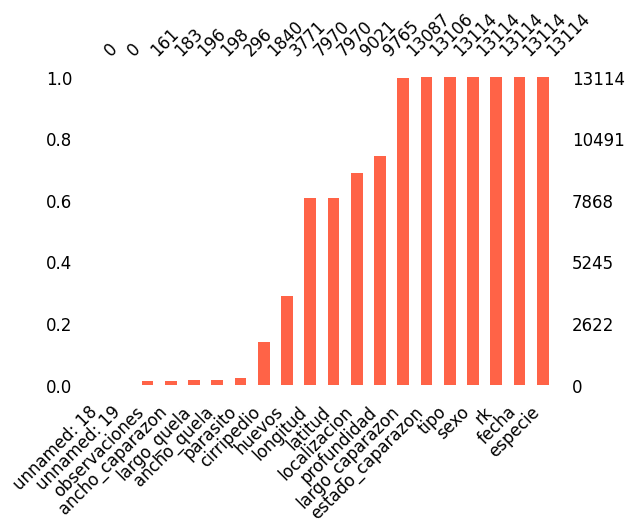

In [114]:
# Visualizacion de valores nulos
msno.bar(df_raw,figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

In [115]:
# Estudio porcentual de valores nulos
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

unnamed: 18         100.00
unnamed: 19         100.00
observaciones        98.77
ancho_caparazon      98.60
largo_quela          98.51
ancho_quela          98.49
parasito             97.74
cirripedio           85.97
huevos               71.24
latitud              39.23
longitud             39.23
localizacion         31.21
profundidad          25.54
largo_caparazon       0.21
estado_caparazon      0.06
dtype: float64


## 1. Limpieza inicial del dataset  

Se eliminan las columnas `unnamed: 18` y `unnamed: 19` ya que no aportan información.

In [116]:
# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
df_raw.drop(columns=['unnamed: 18', 'unnamed: 19'], inplace=True)
df_raw.dropna(subset=['largo_caparazon'],how='any',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 13,087 | Columnas: 18


Las columnas más relevantes para nuestro estudio serán las asociadas a la cantidad de cangrejos en la muestra, su ubicación temporal y espacial, seguido de las características físicas de los mismos.

Puesto que estamos interesados en estudiar la distribución espacial, se eliminan las entradas con localizacion, latitud y altitud simultaneamente nulas. Estos casos no permiten inferir de ninguna manera robusta dónde se realizó la pesca, por lo que se descartan del estudio.



In [117]:
# Elimina la fila SOLO si latitud, longitud y localizacion son NaN simultáneamente
df_raw.dropna(subset=['latitud', 'longitud', 'localizacion'],how='all',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 9,105 | Columnas: 18


Debido al alto porcentaje de entradas nulas, se descartan las columnas `ancho_caparazon`, `largo_quela` y `ancho_quela`, pues no permiten sacar conclusiones sobre la muestra.


In [118]:
df_raw.drop(columns=['ancho_caparazon', 'largo_quela', 'ancho_quela'], inplace=True)

Se procede a limpiar la columna de `tipo` de captura, extrayendo cuando sea posible la cantidad de trampas empleadas durante cada campaña. Esto permite calcular el esfuerzo de captura posteriormente:

In [119]:
df_raw['tipo'].value_counts()

,count
tipo,
Captura total de 4 trampas,895
Captura total de 3 trampas,893
Captura total de 10 trampas,813
Captura total de 2 trampas,709
Captura total de 1 trampa,618
Captura total de 5 trampas,589
Captura total de 2.5 trampas,588
Captura total de 0.75 trampas,461
Captura total de 0.8 trampas,409


In [120]:
def extraer_num_trampas(tipo_str):
    """
    Extrae el número de trampas vinculando explícitamente la cantidad
    con los términos 'trampa' o 'linea'.
    """
    if pd.isna(tipo_str):
        return np.nan

    texto = str(tipo_str).lower()

    # 1. Patrón con número ANTES del término (ej: "10 trampas", "captura de 2 líneas")
    match_antes = re.search(r'(\d+\.?\d*)\s*(?:de\s*)?(trampa|línea|linea)', texto)

    # 2. Patrón con número DESPUÉS del término (ej: "trampas: 10", "línea 2")
    match_despues = re.search(r'(trampa|línea|linea)s?\s*(?::\s*|de\s*)?(\d+\.?\d*)', texto)

    if match_antes:
        numero = float(match_antes.group(1))
        unidad = match_antes.group(2)
    elif match_despues:
        unidad = match_despues.group(1)
        numero = float(match_despues.group(2))
    else:
        # Casos como "Captura total trampas wp 149" (sin cantidad especificada) o muestreos
        return np.nan

    # 3. Conversión de unidades (1 línea = 10 trampas)
    if 'linea' in unidad or 'línea' in unidad:
        return numero * 10.0
    return numero

In [121]:
# Aplicar función
df_raw['num_trampas'] = df_raw['tipo'].apply(extraer_num_trampas)

n_total = len(df_raw)
n_validos = df_raw['num_trampas'].notna().sum()
n_excluidos = n_total - n_validos

print("=="*50)
print(f" Registros con esfuerzo de pesca identificable: {n_validos} ({n_validos/n_total*100:.1f}%)")
print(f" Registros excluidos del cálculo de IAR (índice de abundancia relativa): {n_excluidos} ({n_excluidos/n_total*100:.1f}%)")
print("=="*50)

print("\nCategorías excluidas (sin equivalente en trampas):")
print(df_raw[df_raw['num_trampas'].isna()]['tipo'].value_counts())

 Registros con esfuerzo de pesca identificable: 8865 (97.4%)
 Registros excluidos del cálculo de IAR (índice de abundancia relativa): 240 (2.6%)

Categorías excluidas (sin equivalente en trampas):
tipo
Captura total trampas wp 149    110
Captura por la Wapisa            75
Muestreo de cubierta 3           55
Name: count, dtype: int64


A continuación se calcula el Índice de Abundancia Relativa. El cálculo se hace sobre el dataframe completo, creando una máscara sobre las entradas válidas para este estudio. Se desestiman del cálculo las entradas cuyo tipo de captura sea Desembarque, Muestreo de cubierta y similares. En estos casos, su IAR será NaN.

In [122]:
df_trampas = df_raw[df_raw['num_trampas'].notna()].copy()
print(f"Registros originales: {len(df_raw)}")
print(f"Registros descartados (desembarque, muestreo de cubierta, etc.): {len(df_raw) - len(df_trampas)}")

# 1. Definir la máscara para eventos con número de trampas válido
mask_trampas = df_raw['num_trampas'].notna() & (df_raw['num_trampas'] > 0)

# 2. Inicializar la columna IAR con NaN
df_raw['IAR'] = np.nan

# 3. Contar capturas (número de filas) por cada evento (localizacion, fecha, tipo)
capturas_por_evento = df_raw[mask_trampas].groupby(['localizacion', 'fecha', 'tipo'])['num_trampas'].transform('count')

# 4. Calcular el IAR vectorizado (Capturas / Trampas) para los registros válidos
df_raw.loc[mask_trampas, 'IAR'] = capturas_por_evento / df_raw.loc[mask_trampas, 'num_trampas']

# Presentacion de algunos resultados generales
print(f"\nIAR calculado")
print(f"   Máximo   IAR: {df_raw['IAR'].max():.4f} ({df_raw['IAR'].idxmax()})")
print(f"   Mínimo   IAR: {df_raw['IAR'].min():.4f} ({df_raw['IAR'].idxmin()})")
print(f"   Promedio IAR: {df_raw['IAR'].mean():.4f}")

Registros originales: 9105
Registros descartados (desembarque, muestreo de cubierta, etc.): 240

IAR calculado
   Máximo   IAR: 282.5000 (3866)
   Mínimo   IAR: 0.0600 (3475)
   Promedio IAR: 76.8777


El dataframe de trabajo es el resultado de concatenar dos registros diferentes: al conjunto de datos originales se suma la campaña de jul97 provista posteriormente por nuestra mentora. Para estudiar la evolución temporal de los registros, es necesario ordenar las entradas correctamente.

A continuación se ordena el dataframe de manera que las campañas se sucedan coherentemente en el tiempo.

In [123]:
# Definicion de la prioridad cronologica de las campañas
orden_campanas = {
    'ene_96': 1,
    'abril_96': 2,
    'jul_96': 3,
    'oct_96': 4,
    'jul_97': 5,
    'oct_97': 6,
    'oct_98': 7
}

# Se ordena con 'key' y se reinicia el índice
df_raw = df_raw.sort_values(by='fecha', key=lambda x: x.map(orden_campanas)).reset_index(drop=True)

El porcentaje de nulos del dataframe de trabajo actualmente es el siguiente:

In [124]:
print("="*50)
print("Resumen de limpieza inicial - Estado actual del df")
print("="*50)

print(f"\nFilas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}\n")

# Estudio porcentual de valores nulos
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

Resumen de limpieza inicial - Estado actual del df

Filas: 9,105 | Columnas: 17

observaciones       98.58
parasito            97.25
cirripedio          86.23
huevos              62.47
latitud             12.73
longitud            12.73
IAR                  2.64
num_trampas          2.64
profundidad          1.50
localizacion         1.21
estado_caparazon     0.02
dtype: float64


### 1.1 Composición del dataset limpio

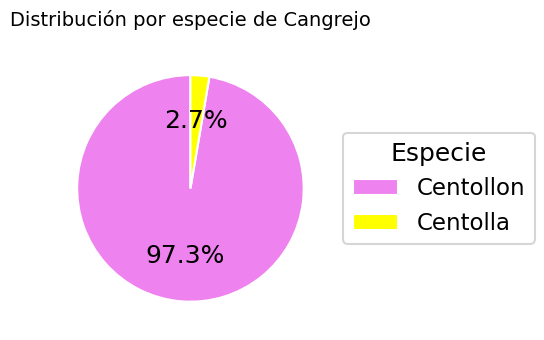

In [125]:
# @title
# Diccionario de mapeo
mapa_especies = {
    1: 'Centolla',
    2: 'Centollon',
    '1': 'Centolla',
    '2': 'Centollon',
}

# Conteo de valores
conteo = df_raw['especie'].value_counts()

# Mapear los índices traducidos para la leyenda
etiquetas = [mapa_especies.get(x, str(x)) for x in conteo.index]

plt.figure(figsize=(5, 4))

# Generar el gráfico asignando los elementos a variables para la leyenda
wedges, texts, autotexts = plt.pie(
    conteo,
    autopct='%1.1f%%',
    colors=sns.color_palette(['violet', 'yellow']),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)

# Agregar la leyenda con las nuevas etiquetas
plt.legend(
    wedges,
    etiquetas,
    title='Especie',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
)

plt.title('Distribución por especie de Cangrejo', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

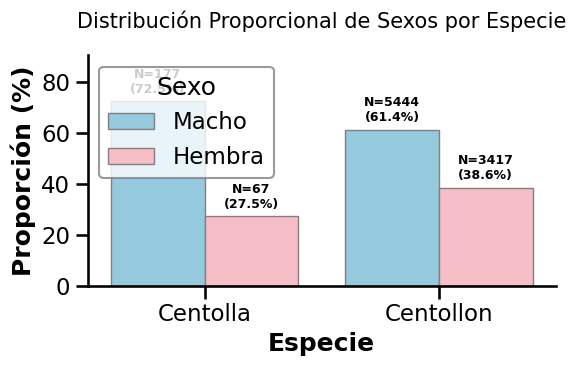

In [126]:
# @title
# Mapeo de codificación
mapa_sexo = {
    1: 'Macho',
    2: 'Hembra'
}

# Aplicar mapeo a una copia del DataFrame
df_plot = df_raw.copy()
df_plot['especie_nom'] = df_plot['especie'].map(mapa_especies)
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo)

# Calcular Conteos (N) y Porcentajes dentro de cada especie
ct_counts = pd.crosstab(df_plot['especie_nom'], df_plot['sexo_nom'])
ct_pct = (
    pd.crosstab(
        df_plot['especie_nom'], df_plot['sexo_nom'], normalize='index'
    )
    * 100
)

# Convertir a formato largo para Seaborn
df_counts = ct_counts.reset_index().melt(
    id_vars='especie_nom', value_name='n_muestras'
)
df_pct = ct_pct.reset_index().melt(
    id_vars='especie_nom', value_name='porcentaje'
)
df_final = pd.merge(df_counts, df_pct, on=['especie_nom', 'sexo_nom'])

# Paleta exacta: Celeste para Macho, Rosa para Hembra
paleta_sexo = {'Macho': '#87CEEB', 'Hembra': '#FFB6C1'}  # Skyblue y Lightpink

orden_especie = ['Centolla', 'Centollon']
orden_sexo = ['Macho', 'Hembra']

# Crear el gráfico
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_final,
    x='especie_nom',
    y='porcentaje',
    hue='sexo_nom',
    order=orden_especie,
    hue_order=orden_sexo,
    palette=paleta_sexo,
    edgecolor='gray',
    linewidth=1,
)

# Agregar el número de muestras (N) sobre cada barra
# (se usa un orden explícito para emparejar cada container con su categoría real,
# en vez de container.get_label(), que no devuelve 'Macho'/'Hembra')
for sexo_cat, container in zip(orden_sexo, ax.containers):
    sub_df = (
        df_final[df_final['sexo_nom'] == sexo_cat]
        .set_index('especie_nom')
        .reindex(orden_especie)
    )
    etiquetas = [
        f"N={int(row['n_muestras'])}\n({row['porcentaje']:.1f}%)"
        for _, row in sub_df.iterrows()
    ]
    ax.bar_label(
        container, labels=etiquetas, padding=4, fontsize=9, fontweight='bold'
    )

# Estética y Caja de Leyenda
plt.title('Distribución Proporcional de Sexos por Especie', fontsize=15, pad=20)
plt.xlabel('Especie', fontweight='bold')
plt.ylabel('Proporción (%)', fontweight='bold')
plt.ylim(
    0, df_final['porcentaje'].max() * 1.25
)  # Margen superior para los textos

# Caja de leyenda
plt.legend(
    title='Sexo',
    loc='upper left',
    frameon=True,
    facecolor='white',
    edgecolor='gray',
)

sns.despine()
plt.tight_layout()
plt.show()

## 2. Corrección de columnas numéricas y categóricas

Estudiemos las variables que quedan con dtype str:  cirripedio, huevos y parasito.

Según la descripcion de los features provistos junto al dataset, hay una serie de columnas cuyos tipos son incorrectos. `estado_caparazon` es flotante en lugar de entero, y las columnas `cirripedio`, `huevos` y `parasito` figuran como str, en lugar de ser variables enteras.

In [127]:
# Copia posterior a la limpieza inicial
df_clean = df_raw.copy()

### 2.1 `estado_caparazon`

La codificación de esta variable es:

- 1 postmuda,
- 2 duro sin epibiontes,
- 3 duro con epibiontes (Spirorbis),
- 4 duro con epibiontes (Balanus),
- 5 duro con 2º caparazón visible,
- 6 exuvia,
- 30 entre estado 2 y 3.

In [128]:
df_clean['estado_caparazon'].value_counts()

,count
estado_caparazon,
3.0,7602
4.0,1207
30.0,153
2.0,130
1.0,7
6.0,2
5.0,2


Los registros no tienen errores en esta variable. No se efectuaron cambios.

### 2.2 `cirripedio`

La codificación de esta variable es:

1–3 (tamaño), sufijo "p" en algunos registros indica presencia en patas. Caso contrario, presencia en caparazón.

NOTA: Los valores decimales reportados significan presencia de cirripedios de diversos tamaños. Por ejemplo, 1.2 se interpreta como que había tamaño 1 y tamaño 2 en caparazón.

In [129]:
df_clean['cirripedio'].value_counts()

,count
cirripedio,
2,797
2.0,370
1,45
3,18
2.3,11
1.0,4
3.0,4
2p,2
1p,1


Debido a que el sufijo 'p' se presentó en únicamente 3 de las >1250 observaciones no nulas, se descartó la creación de una variable indicadora binaria para evitar problemas de varianza nula y desbalance extremo en los pliegues de validación cruzada. Para preservar la integridad del dataset, la variable fue consolidada en su escala numérica base ( 1,2,3 ) removiendo el sufijo marginal. Se conserva solo la caracterizacion de la presencia de cirripedios y no se indica en qué parte del individuo se encuentra, pues para nuestro posterior análisis no resulta relevante tal nivel de detalle.

Se corrije así el tipo de datos str -> float.

In [130]:
# Diccionario de correcciones:
correcciones_cirripedio = {
    '2p': '2',
    '1p': '1'
}

# Aplicar el reemplazo
df_clean['cirripedio'] = df_clean['cirripedio'].replace(correcciones_cirripedio)
df_clean['cirripedio'] = df_clean['cirripedio'].apply(lambda x: float(x))
df_clean['cirripedio'].value_counts()

,count
cirripedio,
2.00,1169
1.00,50
3.00,22
2.30,11
1.20,1
1.23,1


### 2.3 `parasitos`

La codificación de esta variable es:

- 2 isopodo presente,
- 20 isopodo cicatriz,
- 3 rizocefalo presente,
- 30 rizocefalo cicatriz



In [131]:
df_clean['parasito'].value_counts()

,count
parasito,
20,169
2,34
3,18
20.0,16
30,9
2.0,2
"30,20",1
"3,20",1


In [132]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             9105 non-null   object 
 1   rk                9105 non-null   int64  
 2   tipo              9105 non-null   object 
 3   localizacion      8995 non-null   object 
 4   latitud           7946 non-null   float64
 5   longitud          7946 non-null   float64
 6   profundidad       8968 non-null   float64
 7   especie           9105 non-null   int64  
 8   sexo              9105 non-null   int64  
 9   estado_caparazon  9103 non-null   float64
 10  cirripedio        1254 non-null   float64
 11  largo_caparazon   9105 non-null   float64
 12  huevos            3417 non-null   object 
 13  parasito          250 non-null    object 
 14  observaciones     129 non-null    object 
 15  num_trampas       8865 non-null   float64
 16  IAR               8865 non-null   float64


Dado que las muestras con doble categoría representaban únicamente 2 de los 9105 registros totales conservados luego de la limpieza inicial, se descartó la implementación de un esquema multi-etiqueta para evitar problemas de varianza por categorías atípicas. En su lugar, se procedió a reasignar dichas entradas a su categoría principal.

Se reporta la presencia del parásito frente a la cicatriz en el primer caso; y se reporta la cicatriz de la clase minoritaria en el segundo caso.

In [133]:
# Diccionario de correcciones:
correccion_parasito = {
    '3,20': '3', # Priorizo el parasito presente
    '30,20': '30'
}

# Aplicar el reemplazo
df_clean['parasito'] = df_clean['parasito'].replace(correccion_parasito)
df_clean['parasito'] = df_clean['parasito'].apply(lambda x: float(x))
df_clean['parasito'].value_counts()

,count
parasito,
20.0,185
2.0,36
3.0,19
30.0,10


### 2.3 `huevos`

La codificación de esta variable es:

- 0 sin huevos,
- 1 huevos sin ojos,
- 2 huevos sin ojos con mancha blanca,
- 3 huevos con ojos,
- 30 comienzo del estadío 3*,
- 4 eclosionando,
- 40 comienzo del estadío 4*,
- 5 cápsulas vacías (postovígera),
- 6 embriogénesis heterogénea,
- 7 trazas.

Nota: (*) fue información provista por nuestra mentora, no declarada en la documentación original del dataset.

In [134]:
df_clean['huevos'].value_counts()

,count
huevos,
1,1099
0,727
30,455
3.0,231
1.0,217
5,201
6,95
7,89
3,75


In [135]:
# Muestra el registro que tiene huevos = po
df_clean[df_clean['huevos'] == 'po']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
963,abril_96,163,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,2.0,80.7,po,NaN,NaN,2.0,82.0


Las correcciones numéricas sobre los valores observados consisten en unificar tipos de datos, pasando enteros a reales.

Para hacer las correcciones de texto, se estudian en detalle estos casos.



In [136]:
# Estudio de registros particulares huevos = conojos
df_clean[df_clean['huevos'] == 'conojos']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
984,abril_96,73,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,4.0,2.0,73.2,conojos,NaN,NaN,2.0,82.0
1057,abril_96,106,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,4.0,2.0,71.8,conojos,NaN,NaN,2.0,82.0


In [137]:
# Estudio de registros particulares huevos = 7 en 1
df_clean[df_clean['huevos'] == '7 en 1']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
950,abril_96,11,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,92.8,7 en 1,NaN,NaN,2.0,82.0


In [138]:
# Estudio de registro particular huevos = po
df_clean[df_clean['huevos'] == 'po']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
963,abril_96,163,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,2.0,80.7,po,NaN,NaN,2.0,82.0


Se observa que todos los registros atípicos corresponden a la misma campaña y al mismo punto de pesca. Es posible que haya habido desinformación de la codificación de esta variable.

Las correcciones realizadas son las siguientes:

- Los registros cuyo valor es `conojos` se rectifican a 3, interpretando su texto literalmente como "con ojos".

- Los registros cuyo valor es `7 en 1` se rectifican a 1, interpretando su texto una observación sobre la cantidad de huevos sin ojos realizada fuera de su columna homónima.

- Los registros cuyo valor es `po` se descartan por falta de información.

In [139]:
# Registros de hembras cerca de Haskesheska en abril del 96
df_clean[(df_clean['localizacion'] == 'cerca de Haskesheska') & (df_clean['fecha'] == 'abril_96') & (df_clean['sexo'] == 2)]

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,IAR
897,abril_96,157,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,67.2,1,NaN,NaN,2.0,82.0
899,abril_96,151,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,1.0,72.0,NaN,NaN,NaN,2.0,82.0
904,abril_96,156,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,75.1,1,NaN,NaN,2.0,82.0
918,abril_96,144,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,80.2,1,NaN,NaN,2.0,82.0
922,abril_96,140,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,78.1,0,NaN,NaN,2.0,82.0
925,abril_96,137,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,73.9,1,NaN,NaN,2.0,82.0
929,abril_96,133,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,74.5,1,NaN,NaN,2.0,82.0
933,abril_96,129,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,63.4,1,NaN,NaN,2.0,82.0
934,abril_96,160,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,75.5,1,NaN,NaN,2.0,82.0
938,abril_96,31,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,74.3,1,NaN,NaN,2.0,82.0


Se realizan las correcciones mencionadas antes

In [140]:
# Descarte de huevos = po
df_clean = df_clean[df_clean['huevos'] != 'po']

# Diccionario de correcciones:
correccion_huevos = {
    # Corrección de texto
    'conojos': '3',
    '7 en 1': '1'
}

# Aplicar el reemplazo
df_clean['huevos'] = df_clean['huevos'].replace(correccion_huevos)
df_clean['huevos'] = df_clean['huevos'].apply(lambda x: float(x))
df_clean['huevos'].value_counts()

,count
huevos,
1.0,1317
0.0,799
30.0,473
3.0,308
5.0,265
7.0,107
6.0,97
4.0,39
40.0,10


## 3. Segmentación del estudio

En 1.1 se observa que las centollas representan menos del 3% de registros totales. Veamos cómo esta especie fue capturada a lo largo de las distintas temporadas y qué porcentaje de sus registros corresponde a hembras.

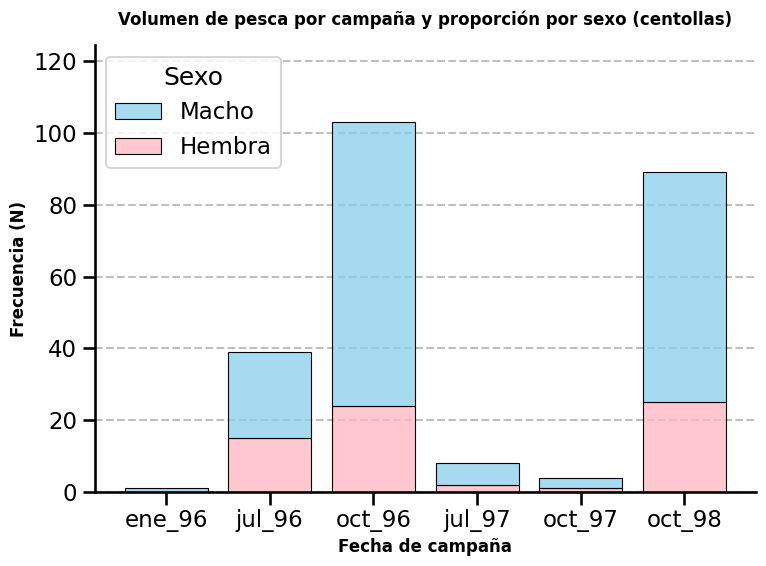

In [141]:
# @title

# Copia de trabajo, enfoque encentollas
df_plot = df_clean[df_clean['especie'] == 1].copy()

# 1. Mapear la columna sexo (1: Macho, 2: Hembra)
mapa_sexo = {1: 'Macho', 2: 'Hembra'}
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo).fillna(df_plot['sexo'])

# 3. Mapeo de colores específicos: Celeste (#87CEEB) para Machos, Rosa (#FFB6C1) para Hembras
paleta_sexo = {'Macho': '#87CEEB', 'Hembra': '#FFB6C1'}

plt.figure(figsize=(8, 6))

# 4. Gráfico de barras apiladas mediante histplot
ax = sns.histplot(
    data=df_plot,
    x='fecha',
    hue='sexo_nom',
    hue_order=['Macho', 'Hembra'],
    multiple='stack',
    palette=paleta_sexo,
    shrink=0.8,
    edgecolor='black',
    linewidth=0.8
)

# 6. Ajuste de escala vertical y estética general
plt.ylim(0, ax.get_ylim()[1] * 1.15)
plt.title('Volumen de pesca por campaña y proporción por sexo (centollas)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Fecha de campaña', fontweight='bold', fontsize=12)
plt.ylabel('Frecuencia (N)', fontweight='bold', fontsize=12)

# Ajustar etiquetas de la leyenda
sns.move_legend(ax, "upper left", title="Sexo", frameon=True)

sns.despine(top=True, right=True)
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

Se observa que sólo las campañas de octubre del 96 y del 98 tuvieron una pesca de más de 80 centollas, y en ningún caso la cantidad de hembras superó los 30 individuos. Los registros disponibles permiten un estudio muy acotado de esta especie, por lo que se decide focalizar el resto del trabajo únicamente en los centollones.   

In [142]:
# Descarte de registros de centollas
df_segmented = df_clean[df_clean['especie'] != 1].copy()

# Tamaño del dataframe segmentado
print(f"Filas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}")

Filas: 8,860 | Columnas: 17


Habiendo segmentado los registros, se agrega una nueva columna booleana indicando si el centollón registrado es sexualmente maduro o no. Para ello, se utiliza el siguiente criterio a partir de información provista por nuestra mentora:

Si el largo del caparazón de un macho es al menos 50,2 mm, este es sexualmente maduro. En el caso de las hembras, su largo debe ser al menos 60,6 mm.

La codificación será entonces:

- 0 sexualmente inmaduro,
- 1 sexualmente maduro

In [143]:
# Condiciones de madurez según sexo y talla (mm)
df_test = df_segmented.copy()
macho_maduro = (df_segmented['sexo'] == 1) & (df_segmented['largo_caparazon'] >= 50.2)
hembra_madura = (df_segmented['sexo'] == 2) & (df_segmented['largo_caparazon'] >= 60.6)

# Nueva columna con codificación 1 (Maduro) y 0 (Inmaduro)
df_segmented['madurez_sexual'] = np.where(macho_maduro | hembra_madura, 1, 0)

# Tamaño del dataframe
print(f"Filas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}")

Filas: 8,860 | Columnas: 18


Este dataframe será el punto de partida para responder a las preguntas solicitadas en este entregable, tomando los subconjuntos pertinentes en cada caso.

## TO-DO - No se modificó.

FALTA HACER TODO EL ANALISIS DE LA PARTE 2 (este tp)

1. Graficar la longitud y la altitud en un mapa
2. Imputar la profundidad usando de referencia altitud y longitud
3. Mostrar EDA del caparazón
4. Grafica temporal mostrando cantidad de trampas muestreadas por expedicion

In [144]:
df = cent_newcorrected.copy()

NameError: name 'cent_newcorrected' is not defined

In [ ]:
# Conservar solo especies con largo de caparazon mayor a 60,6
# Filtrado booleano y reseteo de índice
df = df[df['largo_caparazon'] >= 60.6].reset_index(drop=True)

In [ ]:
df.info()

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ==============================================================================
# CONFIGURACIÓN DEL UMBRAL (Ajuste en unidades de desviación estándar σ)
# ==============================================================================
UMBRAL_SIGMA = 0.5
# ==============================================================================

# 1. Agrupar capturas por localización
df_sexo = df.groupby('localizacion').agg(
    capturas_totales=('sexo', 'count'),
    capturas_hembras=('sexo', lambda x: (x == 2).sum())
).reset_index()

x = df_sexo['capturas_totales']
y = df_sexo['capturas_hembras']

# 2. Recta de tendencia OLS y residuos
m, b = np.polyfit(x, y, 1)
df_sexo['esperado'] = m * x + b
df_sexo['residuo'] = y - df_sexo['esperado']

# Cálculo de la franja simétrica
umbral = UMBRAL_SIGMA * df_sexo['residuo'].std()

# Clasificación de puntos
condiciones = [
    df_sexo['residuo'] > umbral,
    df_sexo['residuo'] < -umbral
]
df_sexo['categoria'] = np.select(
    condiciones,
    ['Hotspot Hembras (+)', 'Dominio Machos (-)'],
    default='Dentro de Franja'
)

# 3. Gráfico base con Plotly Express
fig = px.scatter(
    df_sexo,
    x="capturas_totales",
    y="capturas_hembras",
    text="localizacion",
    color="categoria",
    color_discrete_map={
        'Hotspot Hembras (+)': '#d62728', # Rojo
        'Dominio Machos (-)': '#1f77b4',  # Azul
        'Dentro de Franja': '#7f7f7f'     # Gris
    },
    title=f"Capturas con Franja Paralela de Tolerancia (±{UMBRAL_SIGMA}σ = ±{umbral:.1f} ej.)",
    labels={
        "capturas_totales": "Capturas Totales",
        "capturas_hembras": "Capturas de Hembras",
        "categoria": "Clasificación"
    }
)

# 4. Construir las coordenadas de las líneas paralelas (Superior e Inferior)
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b
y_upper = y_line + umbral
y_lower = y_line - umbral

# 5. Agregar la franja clara (sombreado interno)
fig.add_trace(go.Scatter(
    x=np.concatenate([x_line, x_line[::-1]]),
    y=np.concatenate([y_upper, y_lower[::-1]]),
    fill='toself',
    fillcolor='rgba(220, 220, 220, 0.4)', # Gris claro traslúcido
    line=dict(color='rgba(180, 180, 180, 0.5)', width=1, dash='dot'), # Bordes de la franja
    name='Franja de Esperado',
    hoverinfo='skip'
))

# 6. Agregar la recta central OLS
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    name='Tendencia OLS',
    line=dict(color='black', dash='dash', width=2)
))

# Reordenar capas para que la franja quede al fondo y los puntos arriba
fig.data = (fig.data[-2], fig.data[-1]) + fig.data[:-2]

fig.update_traces(selector=dict(mode='markers+text'), textposition='top center', marker=dict(size=9))
fig.update_layout(height=600)
fig.show()

Coincidencia fuerte (Respuesta afirmativa): Puntos alineados pegados a la línea de tendencia indican que la presencia de hembras es proporcional al volumen total capturado en cada zona.

Hotspots de hembras (Anomalías de interés): Los puntos ubicados muy por encima de la recta corresponden a localizaciones con una proporción atípica de hembras (posibles zonas de reproducción o parición).

Zonas predominantemente masculinas: Los puntos ubicados muy por debajo de la recta representan zonas de gran volumen general pero con baja presencia de hembras.

---

Justificación de los valores de ajuste:

UMBRAL_SIGMA = 1.0 (Permisivo): Captura zonas con variaciones moderadas. Útil para una primera inspección visual exploratoria.

UMBRAL_SIGMA = 1.5 (Recomendado): Umbral balanceado para ecología marina. Selecciona solo las zonas cuya proporción de hembras se aleja fuertemente del promedio general de la pesquería.

UMBRAL_SIGMA = 2.0 (Restrictivo): Detecta únicamente hotspots extremos u outliers estadísticos puros ($>95\%$ de significancia).

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ==============================================================================
# CONFIGURACIÓN DEL ENFOQUE REGULATORIO
# ==============================================================================
# 0.75 sigma: Alta sensibilidad para detectar zonas sensibles (Principio Precautorio)
UMBRAL_SIGMA_REGULATORIO = 0.5
# ==============================================================================

# 1. Agrupar capturas por localización
df_sexo = df.groupby('localizacion').agg(
    capturas_totales=('sexo', 'count'),
    capturas_hembras=('sexo', lambda x: (x == 2).sum())
).reset_index()

x = df_sexo['capturas_totales']
y = df_sexo['capturas_hembras']

# 2. Ajuste de tendencia y cálculo de tolerancia regulatoria
m, b = np.polyfit(x, y, 1)
df_sexo['esperado'] = m * x + b
df_sexo['residuo'] = y - df_sexo['esperado']

sigma = df_sexo['residuo'].std()
techo_regulador = UMBRAL_SIGMA_REGULATORIO * sigma

# 3. Clasificación Unilateral (Conforme vs. Alerta de Infracción/Veda)
df_sexo['alerta_regulatoria'] = np.where(
    df_sexo['residuo'] > techo_regulador,
    'Exceso de Hembras (Posible Zona de Veda/Infracción)',
    'Operación Dentro de Norma'
)

# 4. Gráfico con Plotly Express
fig = px.scatter(
    df_sexo,
    x="capturas_totales",
    y="capturas_hembras",
    text="localizacion",
    color="alerta_regulatoria",
    color_discrete_map={
        'Exceso de Hembras (Posible Zona de Veda/Infracción)': '#d62728', # Rojo
        'Operación Dentro de Norma': '#2ca02c'                           # Verde
    },
    title=f"Monitoreo Regulatorio: Captura de Hembras (Techo Crítico: +{UMBRAL_SIGMA_REGULATORIO}σ = +{techo_regulador:.1f} ej.)",
    labels={
        "capturas_totales": "Capturas Totales (Muestra)",
        "capturas_hembras": "Capturas de Hembras",
        "alerta_regulatoria": "Estado de Control"
    }
)

# 5. Coordenadas del Techo Regulador y Sombreado de Zona Crítica
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b
y_upper = y_line + techo_regulador
y_max_plot = max(y.max(), y_upper.max()) + 10

# Sombreado de la zona de infracción/alerta (por encima del techo)
fig.add_trace(go.Scatter(
    x=np.concatenate([x_line, x_line[::-1]]),
    y=np.concatenate([np.full_like(x_line, y_max_plot), y_upper[::-1]]),
    fill='toself',
    fillcolor='rgba(214, 39, 40, 0.15)', # Rojo traslúcido
    line=dict(color='rgba(214, 39, 40, 0.6)', width=1.5, dash='dash'),
    name='Zona de Alerta (Exceso de Hembras)',
    hoverinfo='skip'
))

# Línea base de tendencia OLS
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    name='Proporción Promedio Esperada',
    line=dict(color='gray', dash='dot', width=1.5)
))

# Enviar capas de fondo al atrás
fig.data = (fig.data[-2], fig.data[-1]) + fig.data[:-2]

fig.update_traces(selector=dict(mode='markers+text'), textposition='top center', marker=dict(size=10))
fig.update_layout(height=600)
fig.show()

In [ ]:
# 1. Definir la secuencia cronológica real de las campañas
orden_campanas = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']

# 2. Transformar la columna a Categorical con orden estricto (reemplaza 'temporada' por tu columna)
df['fecha'] = pd.Categorical(
    df['fecha'],
    categories=orden_campanas,
    ordered=True
)

# 3. Crear una columna datetime real para permitir gráficos de ejes continuos
mapa_fechas = {
    'ene_96': '1996-01-01',
    'abril_96': '1996-04-01',
    'jul_96': '1996-07-01',
    'oct_96': '1996-10-01',
    'jul_97': '1997-07-01',
    'oct_97': '1997-10-01',
    'oct_98': '1998-10-01'
}
df['fecha_campana'] = pd.to_datetime(df['fecha'].map(mapa_fechas))

# 4. Reordenar el DataFrame físicamente y reiniciar el índice
df = df.sort_values(by='fecha').reset_index(drop=True)

In [ ]:
df_raw['fecha'].unique()

In [ ]:
plt.figure(figsize=(10, 6))

# 1. Gráfico de conteo directo con la columna str original
ax = sns.countplot(
    data=df,
    x='fecha',
    hue='fecha',
    palette='Blues_r',
    legend=False,
    edgecolor='black',
    linewidth=0.8,
)

# 2. Total de registros no nulos para calcular el porcentaje
total = df['fecha'].notna().sum()

# 3. Anotar N y % sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = 100 * height / total
        ax.annotate(
            f'N={int(height)}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color='#2c3e50',
        )

# 4. Ajuste dinámico del margen superior para evitar corte de texto
plt.ylim(0, ax.get_ylim()[1] * 1.20)

# Estética
plt.title(
    'Volumen de pesca por campaña',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Fecha de campaña', fontweight='bold')
plt.ylabel('Frecuencia (N)', fontweight='bold')

sns.despine(top=True, right=True)
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

huevos_map = {
    0: 'Sin huevos', 1: 'Con huevos', 2: 'Con huevos',
    3: 'Con huevos', 4: 'Eclosionado', 5: 'Sin huevos',
    6: 'Sin huevos', 7: 'Sin huevos'
}

df_plot = df.copy()

# Mapeo de sexo (1: Macho, 2: Hembra)
mapa_sexo = {1: 'Macho', 2: 'Hembra'}
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo).fillna(df_plot['sexo'])

# Conversión y filtrado numérico de estado de huevos (0-7)
huevos_num = pd.to_numeric(df_plot['huevos'], errors='coerce')

# Filtrado exclusivo de hembras (sexo == 2 o 'Hembra') con registro de huevos válido
hembras = df_plot.loc[
    ((df_plot['sexo'] == 2) | (df_plot['sexo_nom'] == 'Hembra')) &
    huevos_num.between(0, 7)
].copy()

hembras['estado_huevos'] = huevos_num.loc[hembras.index].map(huevos_map)

# Orden cronológico de campañas
orden_temporada = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']

# Tabla de frecuencias relativas (%) y tamaños muestrales
tab_huevos = pd.crosstab(hembras['fecha'], hembras['estado_huevos'], normalize='index') * 100
tab_huevos = tab_huevos.reindex(orden_temporada)
n_temporada = hembras.groupby('fecha').size().reindex(orden_temporada)

# Generación del gráfico
fig, ax = plt.subplots(figsize=(10, 5.5))
tab_huevos.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='white', linewidth=0.5)

etiquetas_x = [f"{t}\n(N={int(n_temporada[t]) if pd.notna(n_temporada[t]) else 0})" for t in orden_temporada]
ax.set_xticklabels(etiquetas_x, rotation=45, ha='right')
ax.set_xlabel('Temporada de muestreo', fontweight='bold')
ax.set_ylabel('% de hembras', fontweight='bold')
ax.set_title('Estado de desarrollo de los huevos en hembras, por temporada', fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Estado', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='gray')

sns.despine()
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Coordenadas promedio por localización
coords_por_loc = df_raw.dropna(subset=['latitud', 'longitud']).groupby('localizacion').agg(
    latitud=('latitud', 'mean'),
    longitud=('longitud', 'mean')
).reset_index()

# Unir con el IAR agregado
mapa_iar = coords_por_loc.merge(
    iar_por_loc.reset_index(),
    left_on='localizacion', right_on='Localización',
    how='inner'
)

fig_todos = px.scatter_map(
    mapa_iar,
    lat="latitud",
    lon="longitud",
    size="IAR_Total",
    color="IAR_Total",
    color_continuous_scale="YlOrRd",
    hover_name="localizacion",
    hover_data={"N_Capturas": True, "N_Trampas": True, "IAR_Total": ':.3f'},
    zoom=8,
    map_style="open-street-map",
    title="IAR en todas las localizaciones — picos de concentración visibles"
)
fig_todos.update_layout(
    mapbox_bounds={
        "west": mapa_iar.longitud.min(),
        "east": mapa_iar.longitud.max(),
        "south": mapa_iar.latitud.min(),
        "north": mapa_iar.latitud.max()
    }
)
fig_todos.show()